In [8]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
from tqdm.auto import tqdm
import jax.numpy as jnp
import matplotlib.pyplot as plt
import odds_datasets

0it [00:00, ?it/s]

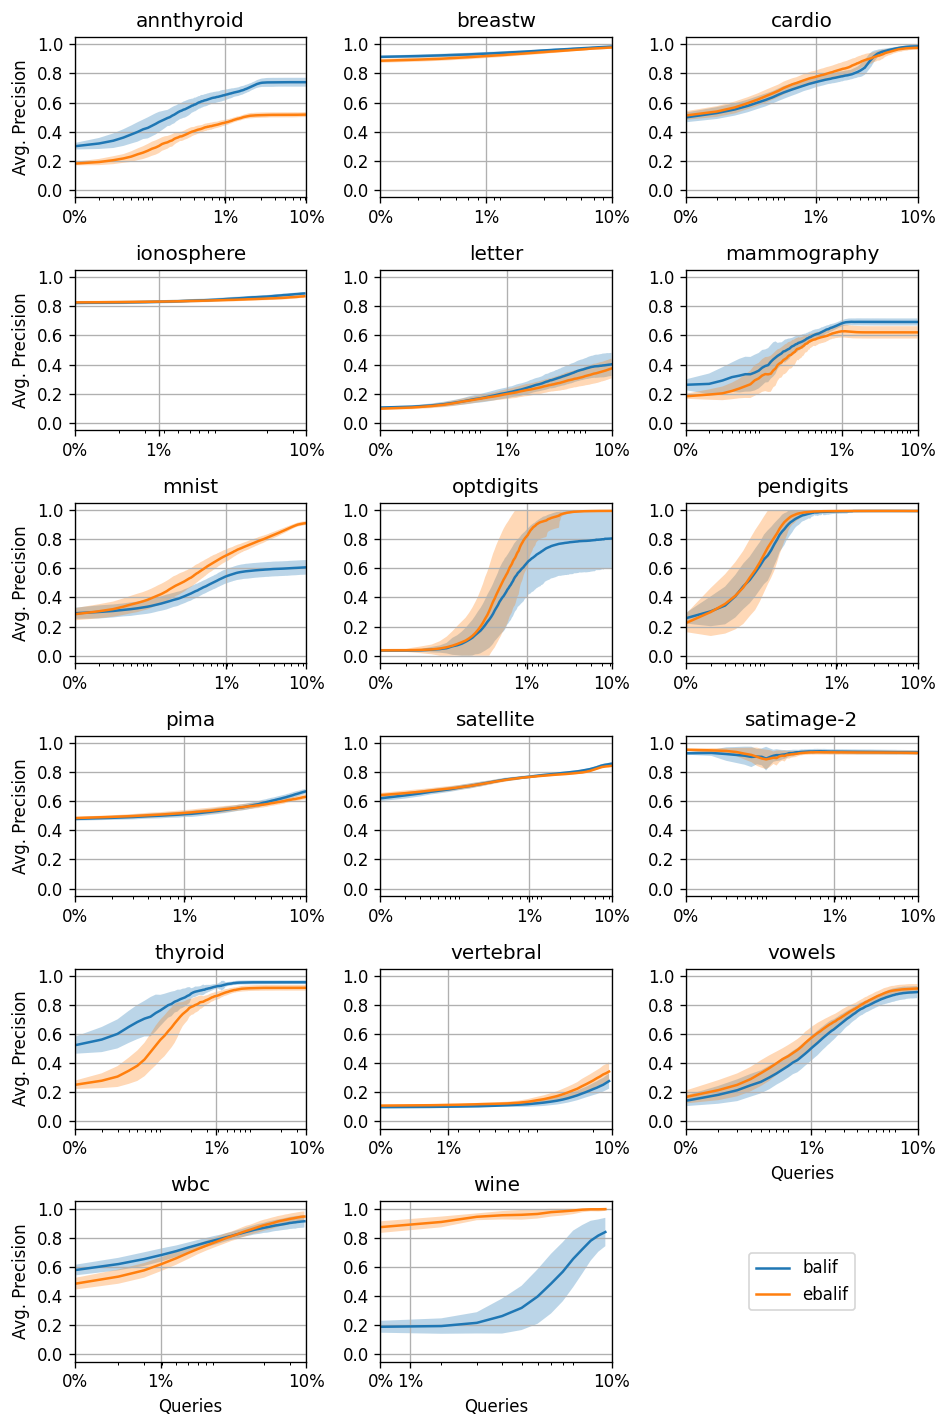

In [11]:
plt.figure(figsize=(2 * 4, 3 * 4), dpi=120)
for i, dataset_name in tqdm(
    enumerate(sorted(odds_datasets.datasets_names) + ["legend"])
):
    plt.subplot(6, 3, i + 1)
    for model_name, label in [
        ("balif", "balif"),
        ("ebalif_perc", "ebalif"),
        # ("balif_geom", "balif_g"),
        # ("ebalif_geom", "ebalif_g"),
    ]:
        if dataset_name == "legend":
            plt.plot(0, 0, label=label)
        else:
            ap = jnp.load(f"results/{dataset_name}_{model_name}.npy", allow_pickle=True)
            ap_mean, ap_std = ap.mean(axis=0), ap.std(axis=0)
            plt.semilogx(1 + jnp.arange(len(ap_mean)), ap_mean, label=label)
            plt.fill_between(
                1 + jnp.arange(len(ap_mean)),
                jnp.maximum(0, ap_mean - ap_std),
                jnp.minimum(1, ap_mean + ap_std),
                alpha=0.3,
            )

    if dataset_name == "legend":
        plt.title("")
        plt.legend(loc="center")
        plt.axis("off")
    else:
        plt.title(dataset_name)
        if i >= 14:
            plt.xlabel("Queries")
        if i % 3 == 0:
            plt.ylabel("Avg. Precision")
        plt.ylim(-0.05, 1.05)
        plt.xlim(1, len(ap_mean) + 1)
        plt.xticks([1, (len(ap_mean) + 1) / 10, len(ap_mean) + 1], labels=["0%", "1%", "10%"])
        plt.yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
        plt.grid()

plt.tight_layout()
plt.savefig(f"figures/ap_evolution/ap_all.pdf", bbox_inches="tight")
plt.show()

0it [00:00, ?it/s]

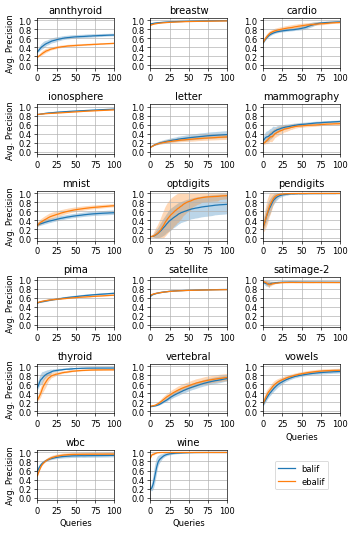

In [ ]:
plt.figure(figsize=(2*3,3*3), dpi=60)
for i, dataset_name in tqdm(enumerate(sorted(odds_datasets.datasets_names)+["legend"])):
    plt.subplot(6, 3, i+1)
    # plt.figure(figsize=(5/2,3/2), dpi=60)
    # if dataset_name == "legend":
    #     plt.figure(figsize=(5/2,3/2), dpi=60)
    for model_name in ["balif", "ebalif"]:
        if dataset_name == "legend":
            plt.plot(0,0, label=model_name) 
        else:
            ap = jnp.load(f"results/{dataset_name}_{model_name}_100_queries.npy", allow_pickle=True)
            ap_mean, ap_std = ap.mean(axis=0), ap.std(axis=0)
            plt.plot(ap.mean(axis=0), label=model_name)
            plt.fill_between(
                range(len(ap_mean)),
                jnp.maximum(0, ap_mean - ap_std),
                jnp.minimum(1, ap_mean + ap_std),
                alpha=0.3,
            )

    if dataset_name == "legend":
        plt.title("")
        plt.legend(loc="center")
        plt.axis('off')
    else:
        plt.title(dataset_name)
        if i >= 14:
            plt.xlabel("Queries")
        if i % 3 == 0:
            plt.ylabel("Avg. Precision")
        plt.ylim(-0.05, 1.05)
        plt.xlim(0, 100)
        plt.xticks([0,25,50,75,100])
        plt.yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
        # data, labels = odds_datasets.load(dataset_name)
        # plt.xlim(0, data.shape[0]//10)
        plt.grid()

plt.subplots_adjust(wspace=0.2, hspace=0.1)
plt.tight_layout()
plt.savefig(f"figures/ap_evolution/ap_all.pdf", bbox_inches="tight")

plt.show()